<a href="https://colab.research.google.com/github/michellejeanmunira/ict-use-of-teachesrs/blob/my-ict/ICT_use.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from scipy.stats import chi2_contingency, ttest_ind
import statsmodels.api as sm

mounting the drive and loading the dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/diabetes/gai _teacher.csv'
df = pd.read_csv(file_path)
print(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
                      Timestamp Full Name of the Teacher:\n  Whatsapp Contact  \
0   2025/04/23 9:01:46 am GMT+3           Tibakanya Joseph                NaN   
1   2025/04/23 9:40:41 am GMT+3           Tibakanya Joseph                NaN   
2  2025/04/23 10:33:45 am GMT+3                      knm,n,               NaN   
3  2025/04/24 10:25:14 am GMT+3     BYANSIBYAKUREKA BALION        781878342.0   
4  2025/04/24 10:25:14 am GMT+3              Damba Jackson        784811353.0   

                Personal Email Address Education Service Status Age Range  \
0                                  NaN                      NaN     35–44   
1                                  NaN                      NaN     25–34   
2                                  NaN                      NaN     35–44   
3  byansibyakurekabalion2019@gmail.com                      AEP     25–34   

data inspection

In [ ]:
df.shape

(247, 54)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247 entries, 0 to 246
Data columns (total 54 columns):
 #   Column                                                                                                                                                          Non-Null Count  Dtype  
---  ------                                                                                                                                                          --------------  -----  
 0   Timestamp                                                                                                                                                       247 non-null    object 
 1   Full Name of the Teacher:
                                                                                                                                      247 non-null    object 
 2   Whatsapp Contact                                                                                                                      

In [ ]:
df.describe()

,Whatsapp Contact,How confident are you in using ICT tools for teaching and learning?
count,2.440000e+02,247.00000
mean,1.336143e+10,3.54251
std,5.547003e+10,1.08445
min,7.022677e+08,1.00000
25%,7.707249e+08,3.00000
50%,7.772104e+08,4.00000
75%,7.830749e+08,4.00000
max,2.567866e+11,5.00000


In [ ]:
df.isnull().sum()

,0
Timestamp,0
Full Name of the Teacher:\n,0
Whatsapp Contact,3
Personal Email Address,3
Education Service Status,3
Age Range,0
Gender,0
Highest Level of Education Completed:,0
Number of Years of Teaching Experience:,0
Are you currently teaching under the Accelerated Education Programme (AEP)?,0


In [ ]:
df.duplicated().sum()

np.int64(0)

heat map

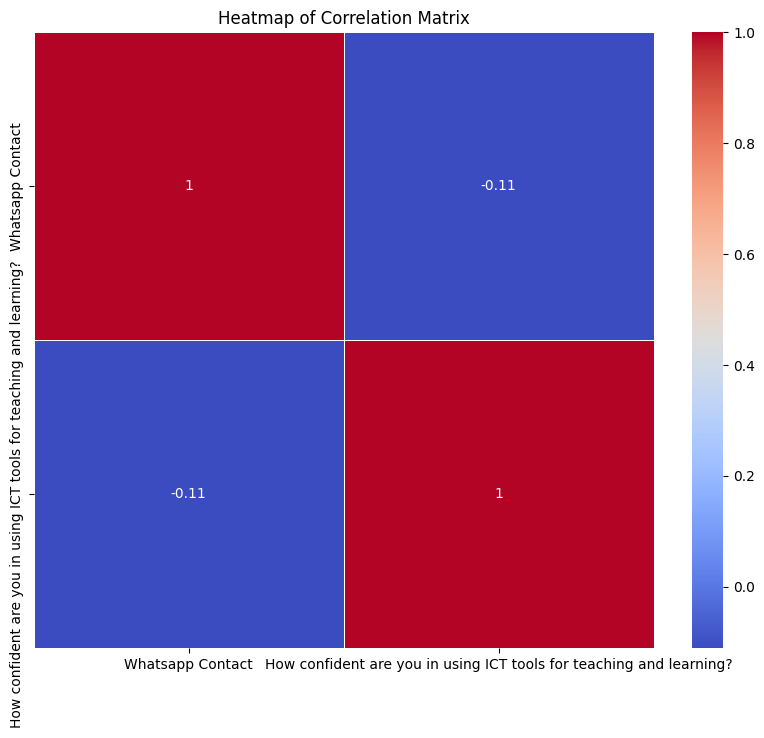

In [ ]:

numeric_df = df.select_dtypes(include=['number'])
corr_matrix = numeric_df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Heatmap of Correlation Matrix')
plt.show()

Cleaned DataFrame Columns:
['Timestamp', 'Full Name of the Teacher:', 'Whatsapp Contact', 'Personal Email Address', 'Education Service Status', 'Age Range', 'Gender', 'Highest Level of Education Completed:', 'Number of Years of Teaching Experience:', 'Are you currently teaching under the Accelerated Education Programme (AEP)?', 'Do you teach the Accelerated Learning Curriculum (AEP)?', 'Which subject(s) do you currently teach?\n(Tick all that apply)', 'Have you taught learners in refugee or displaced community settings?', 'How long have you taught in refugees or displaced community settings?', 'How confident are you in using ICT tools for teaching and learning?', 'How confident are you in using ICT tools for teaching and learning?.1', 'Have you received any formal training in the use of ICT for education?', 'Do you currently have access to the following in your school/classroom? (Tick all that apply)', 'Do you have a personal device you can use for teaching or accessing learning materi

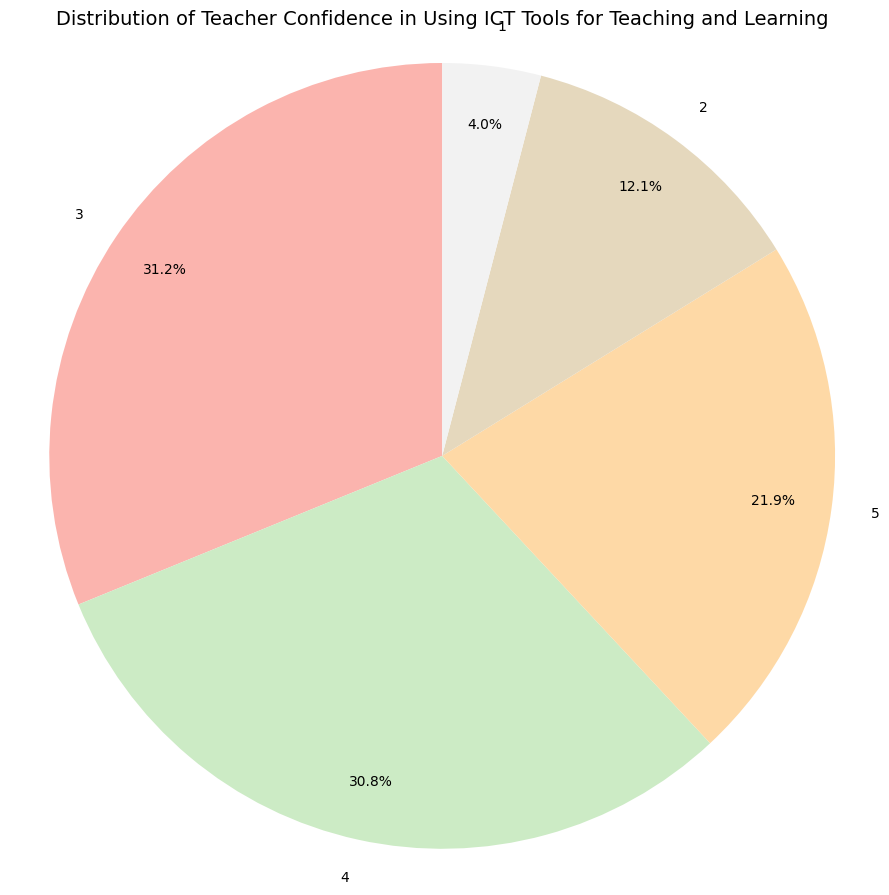


Generating stacked bar charts for single-select variables:


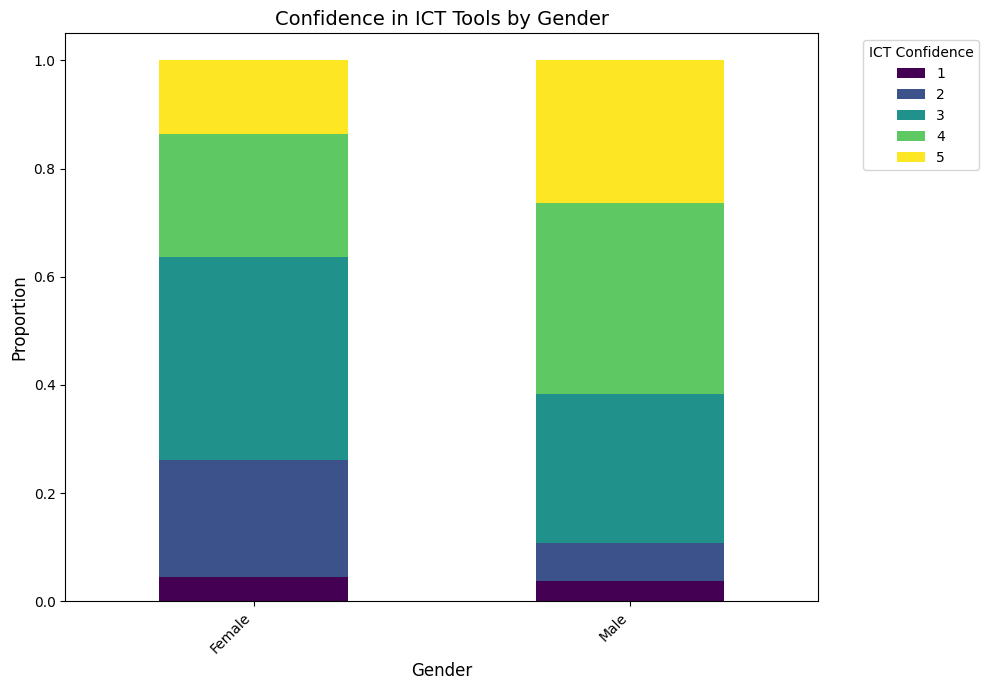

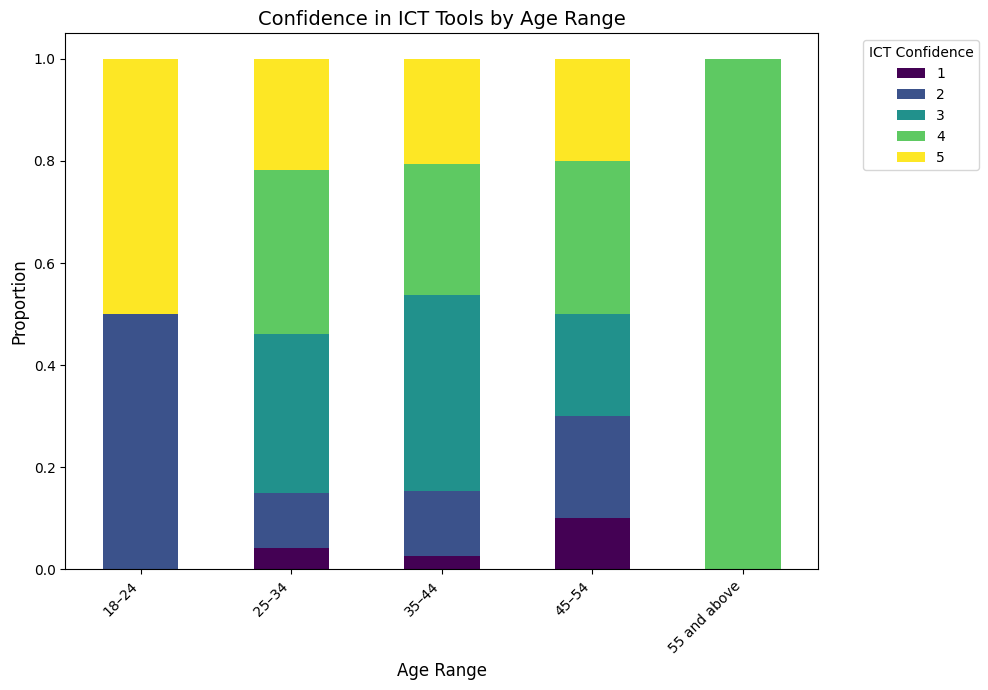

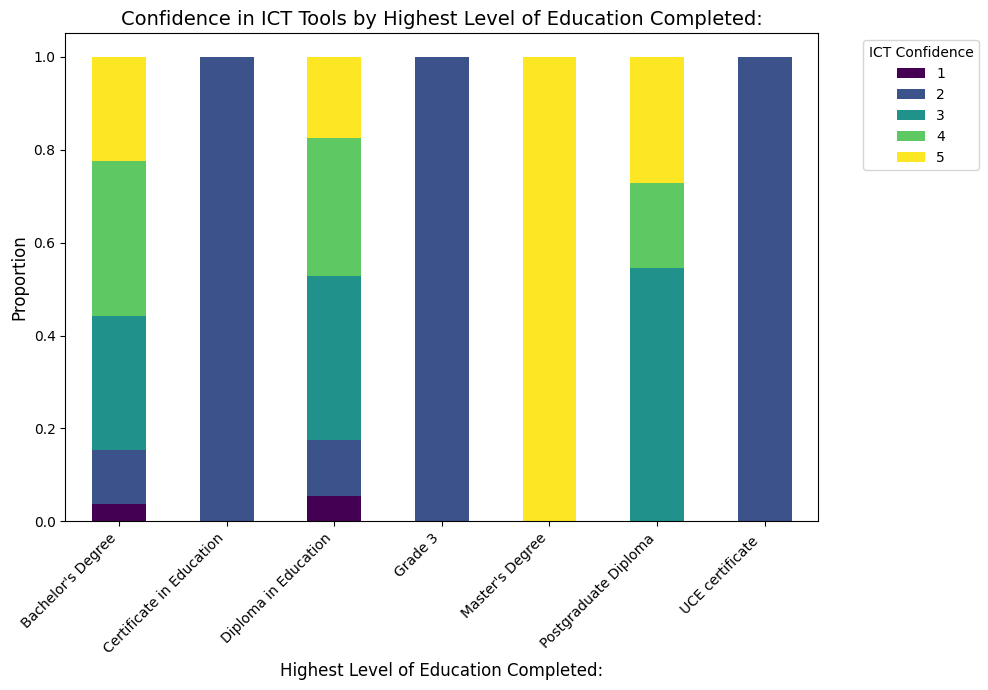

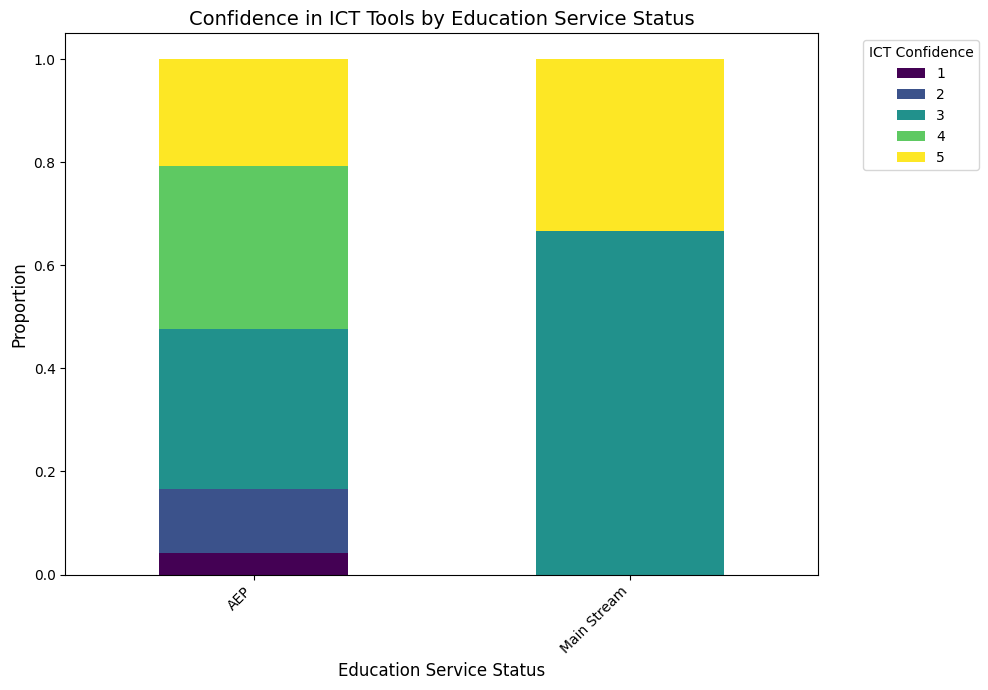

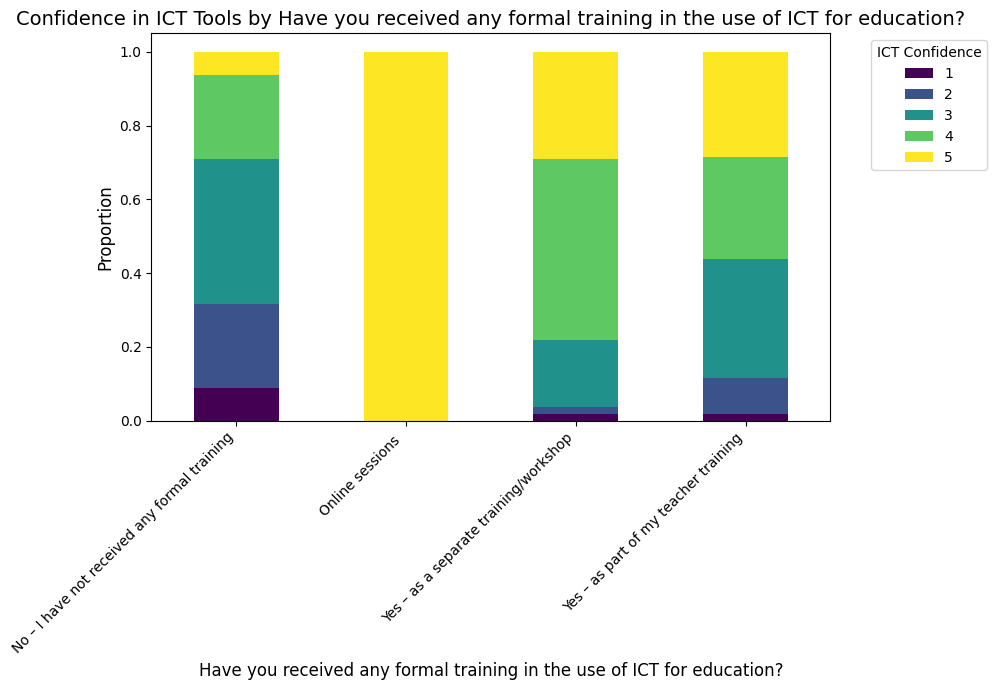

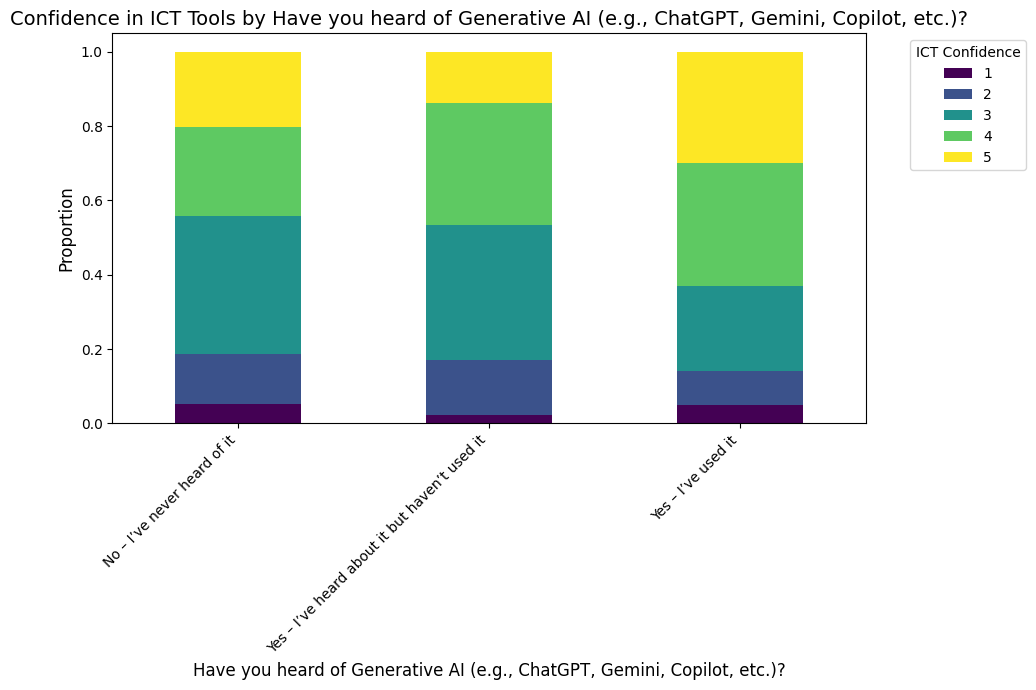


Generating stacked bar charts for present multi-select variables:


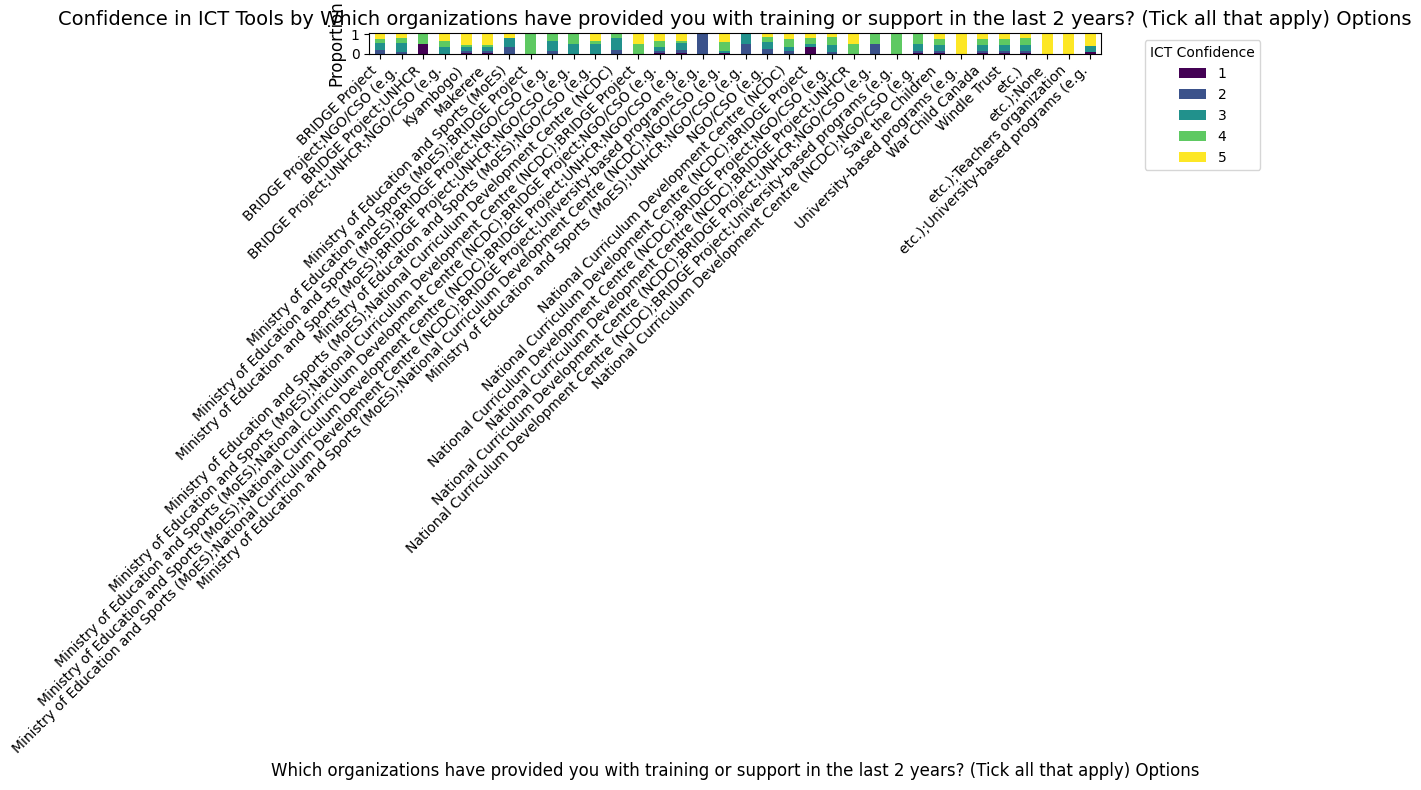

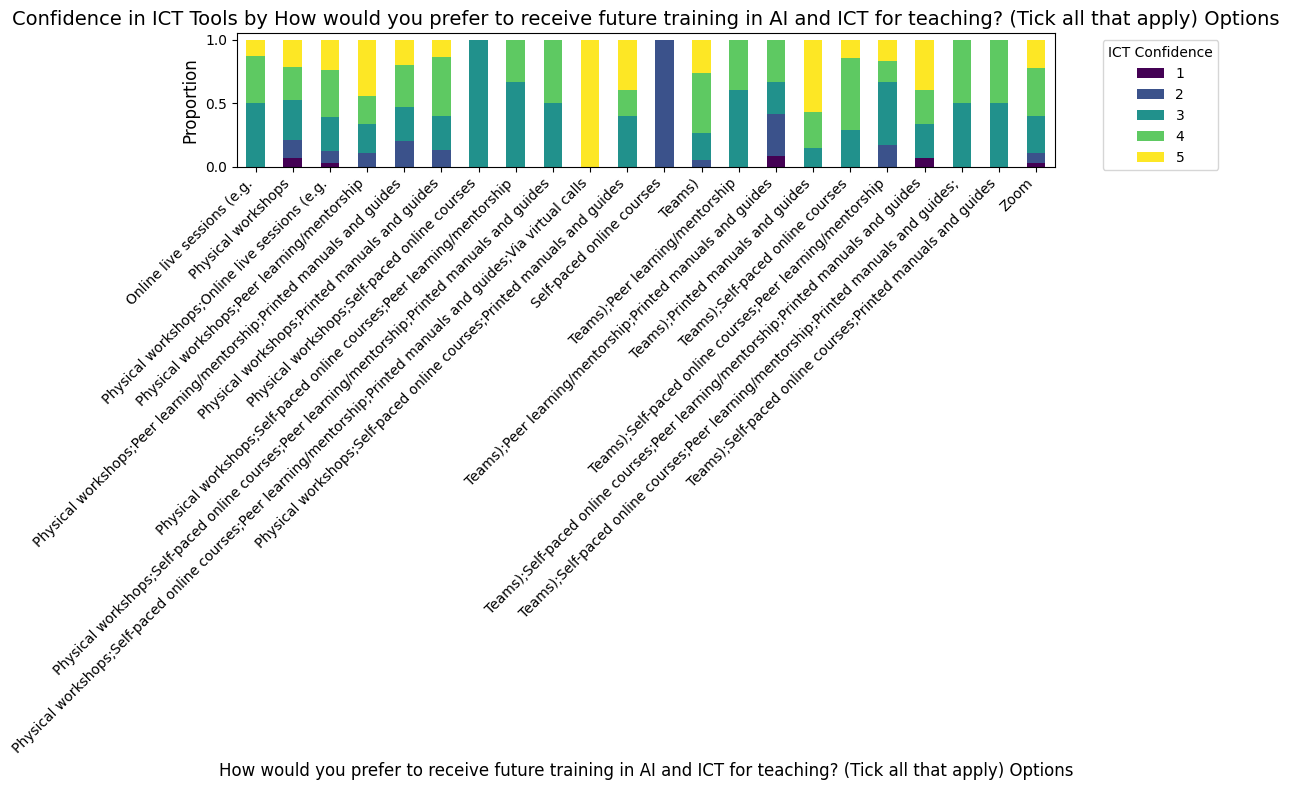

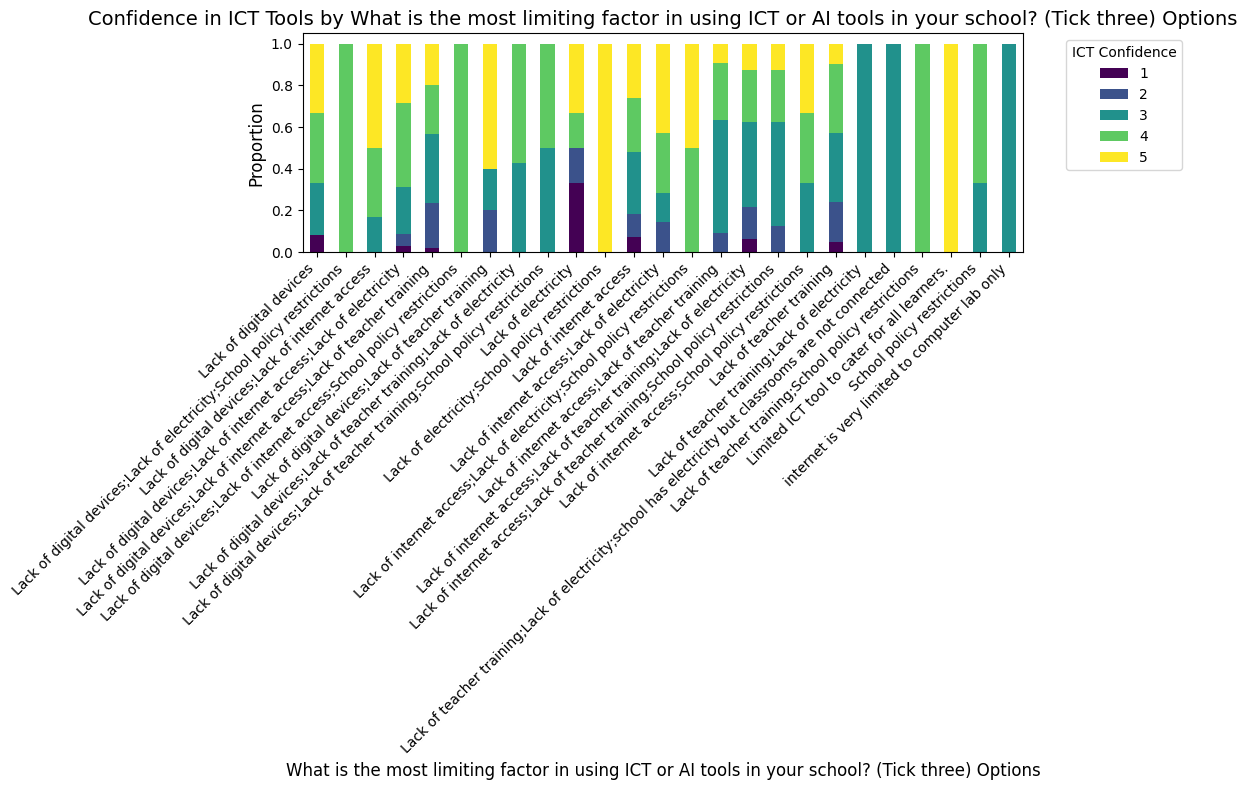

<ipython-input-23-2c8b843bc9b8>:134: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


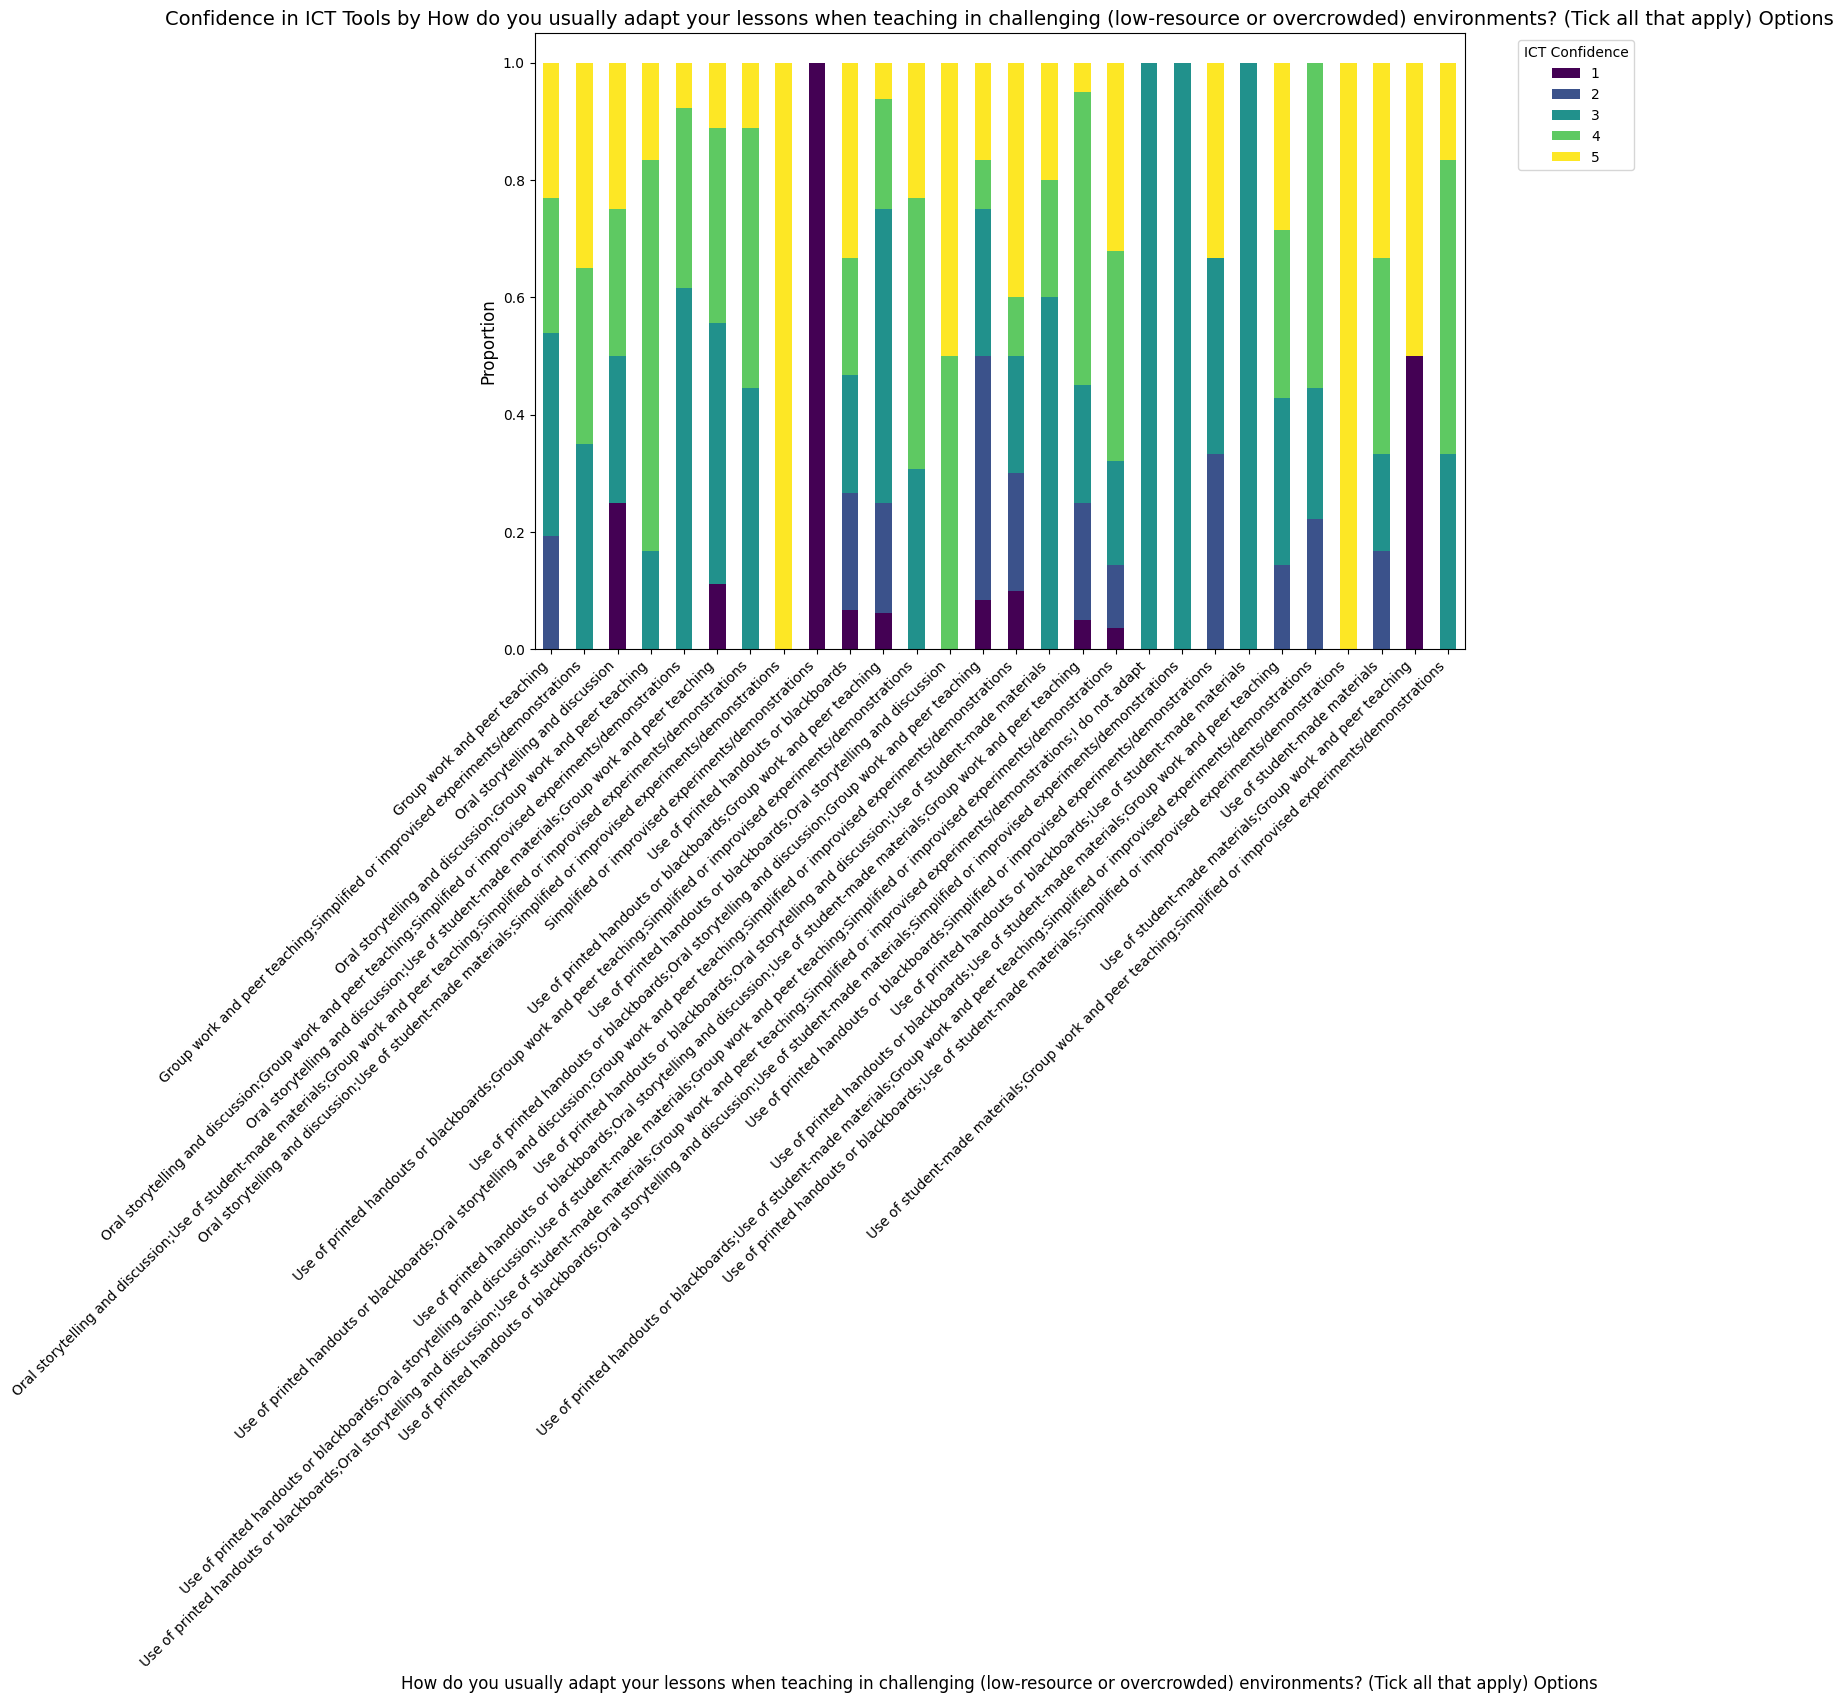

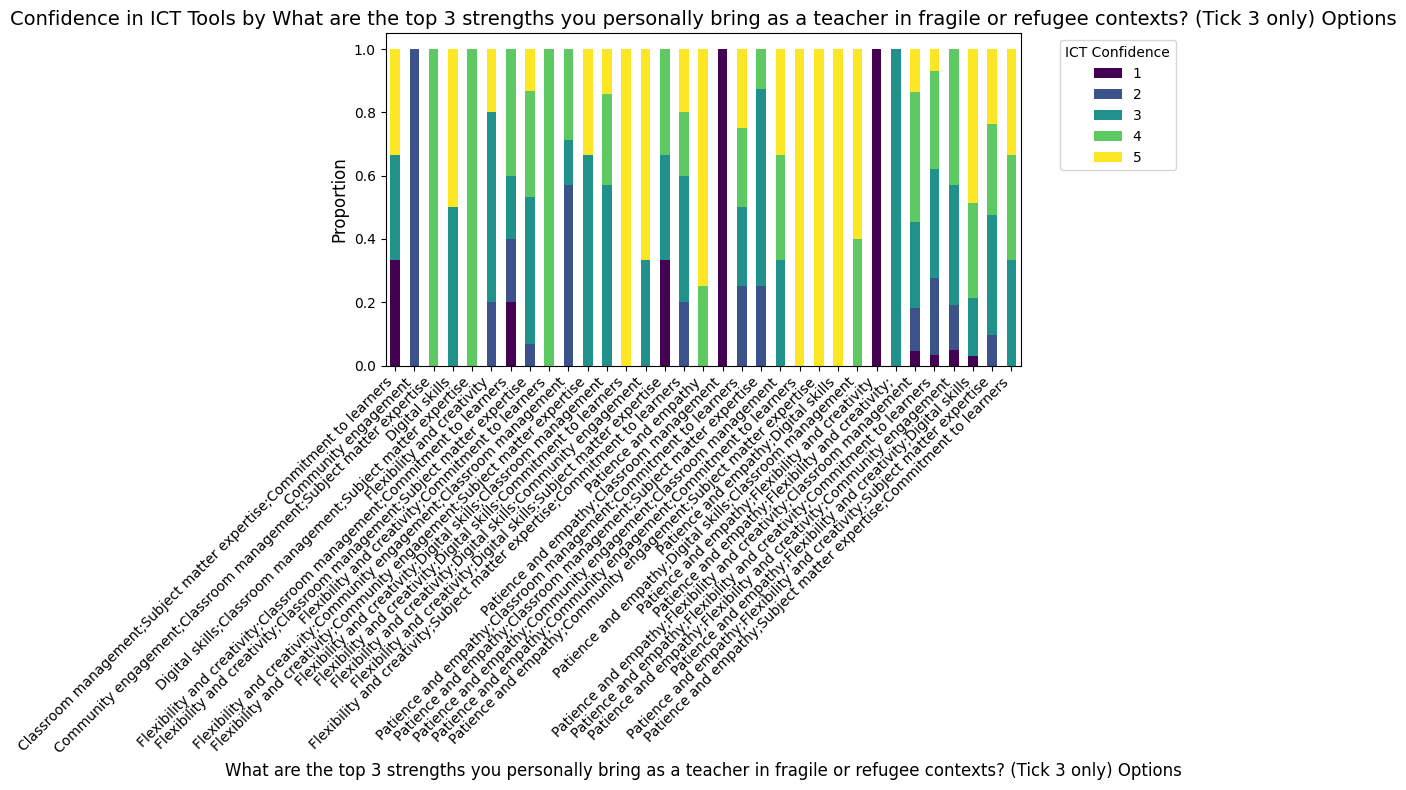

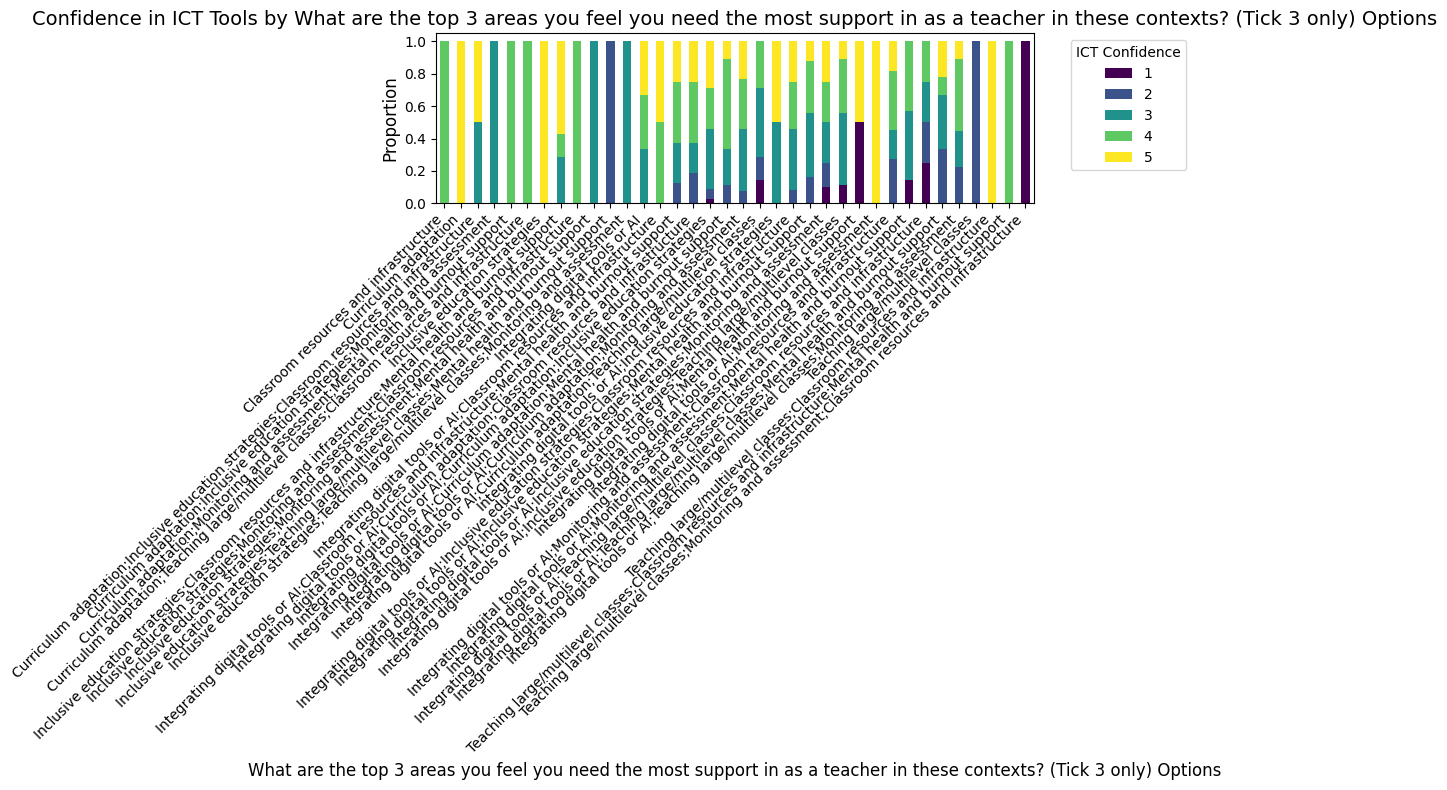

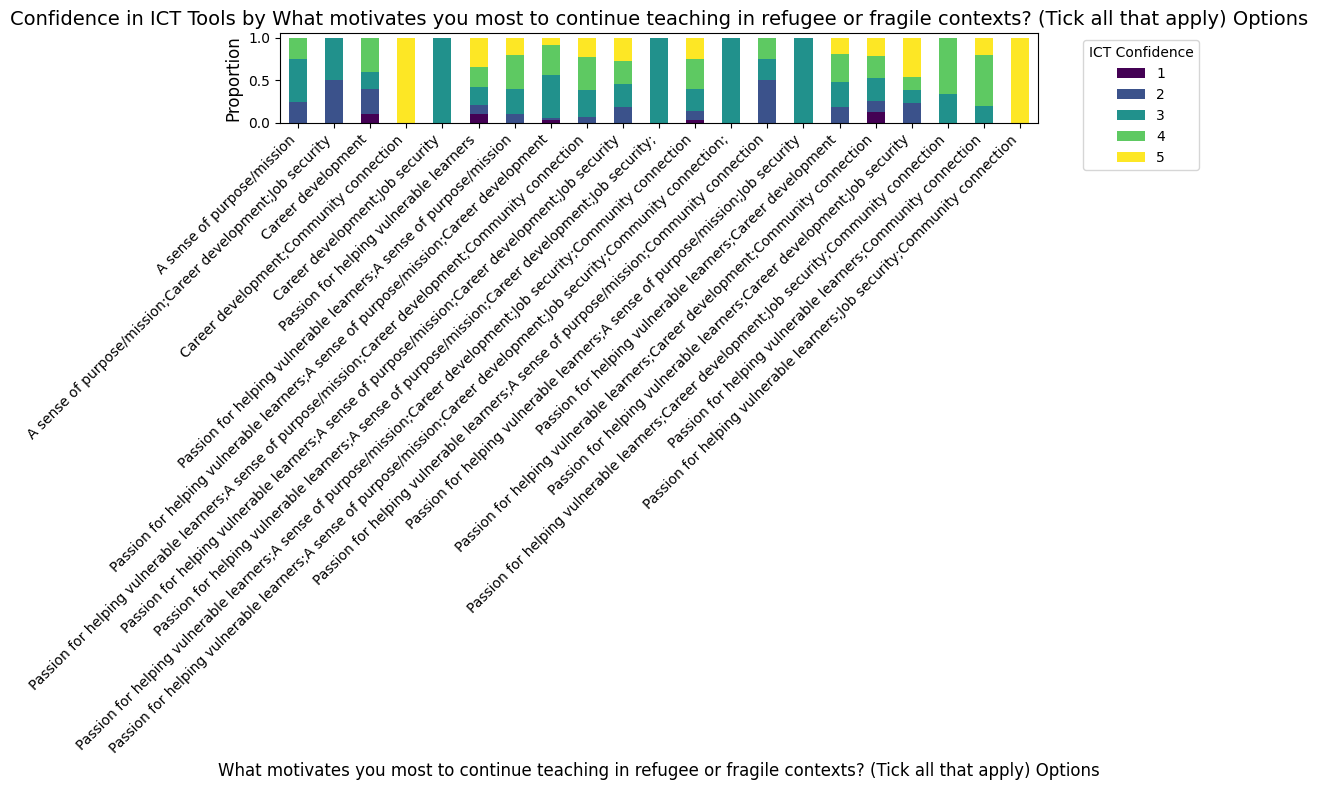

<ipython-input-23-2c8b843bc9b8>:134: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


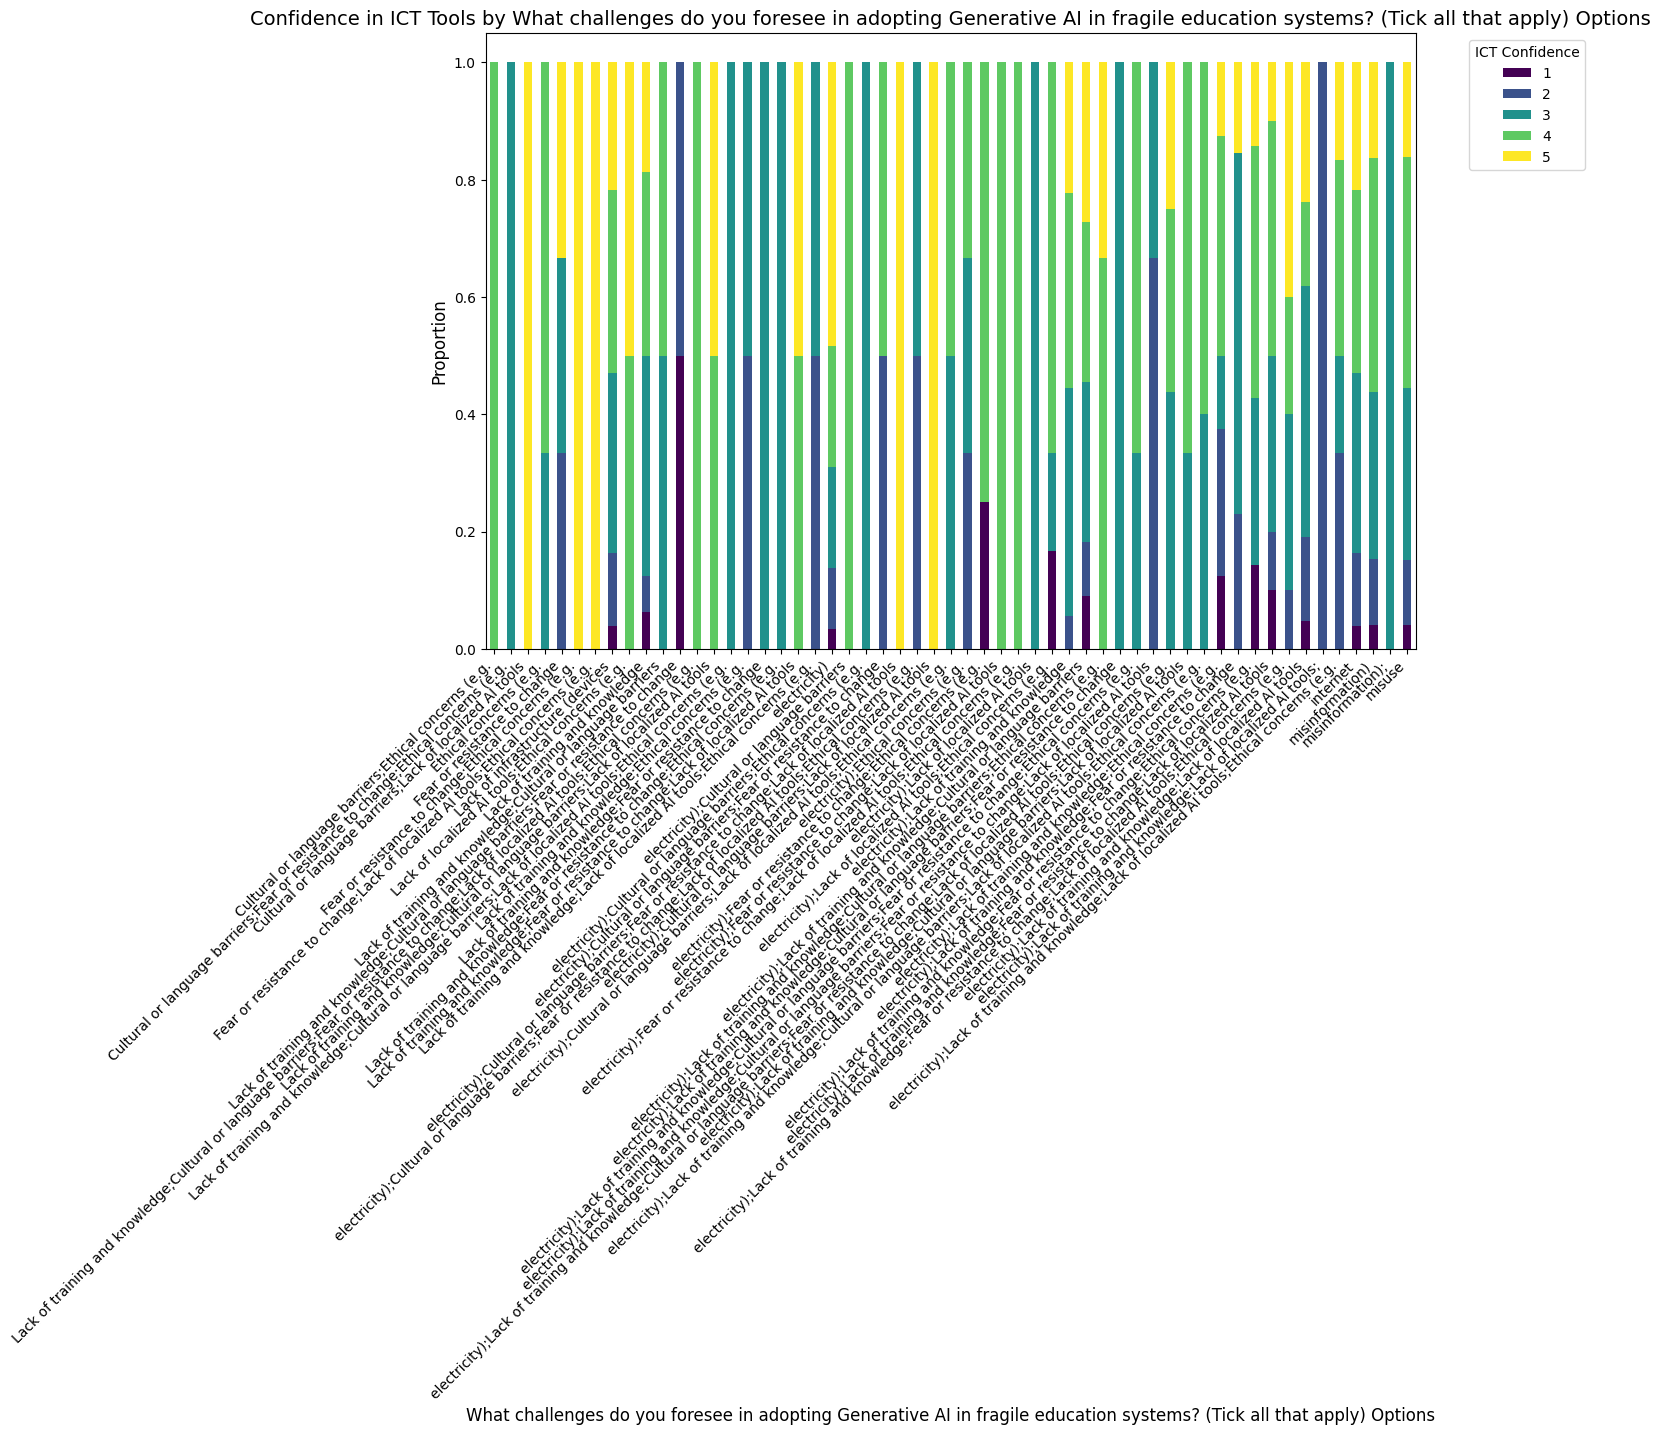

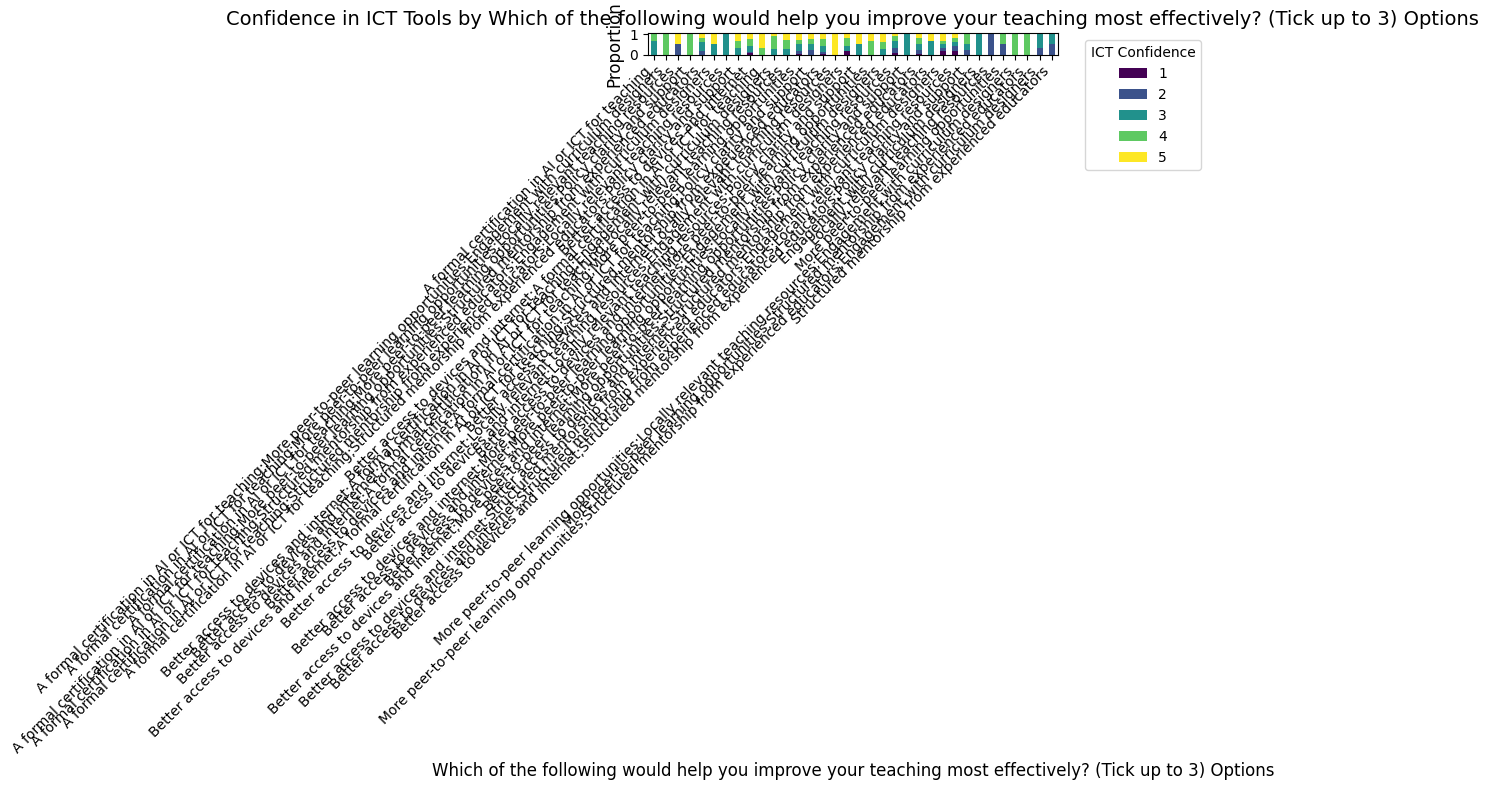

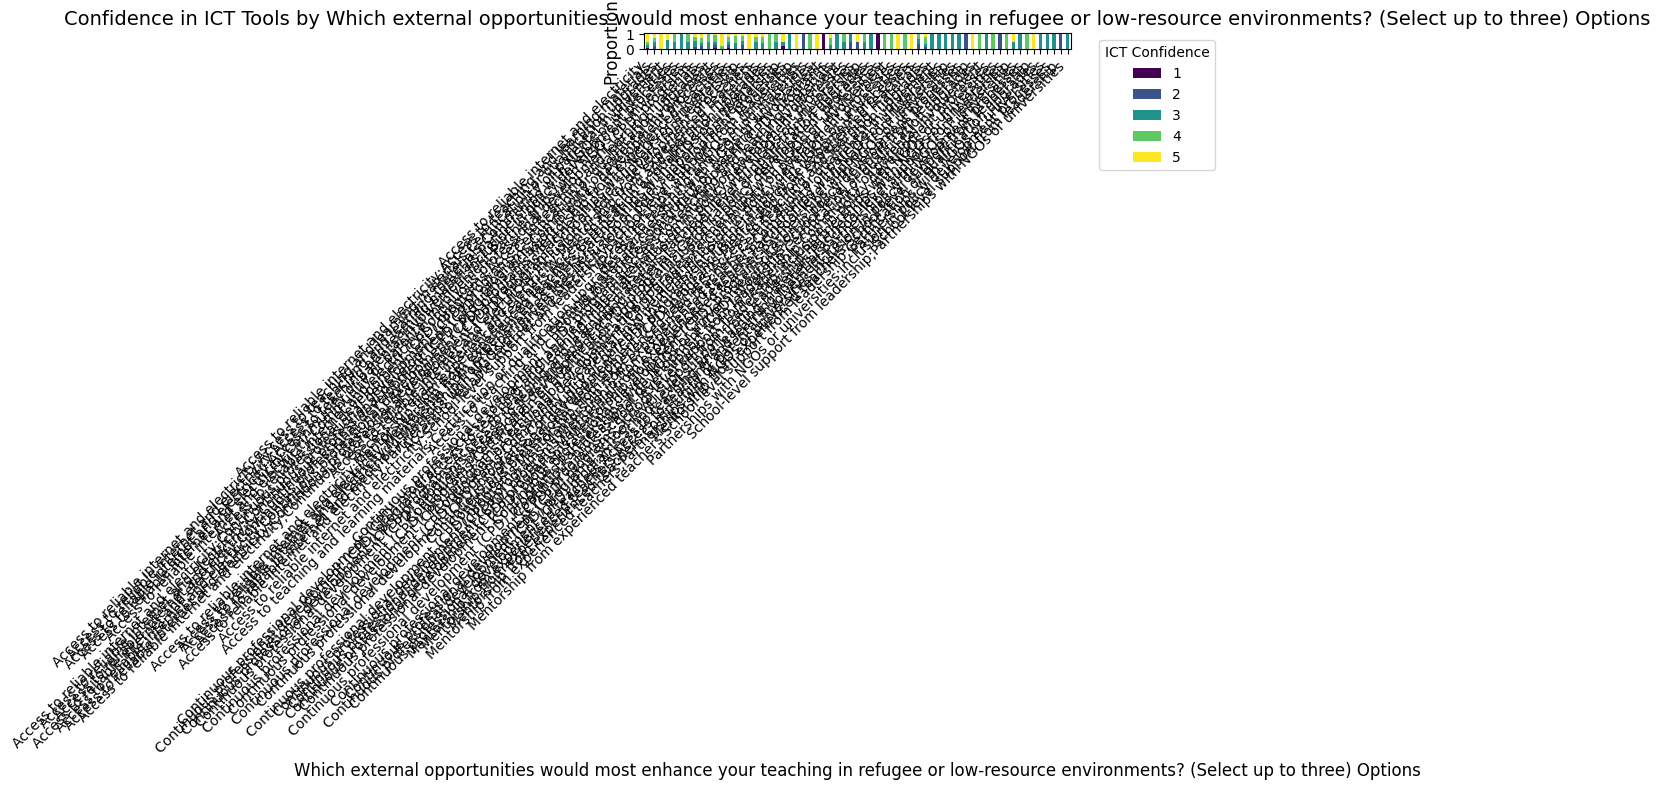

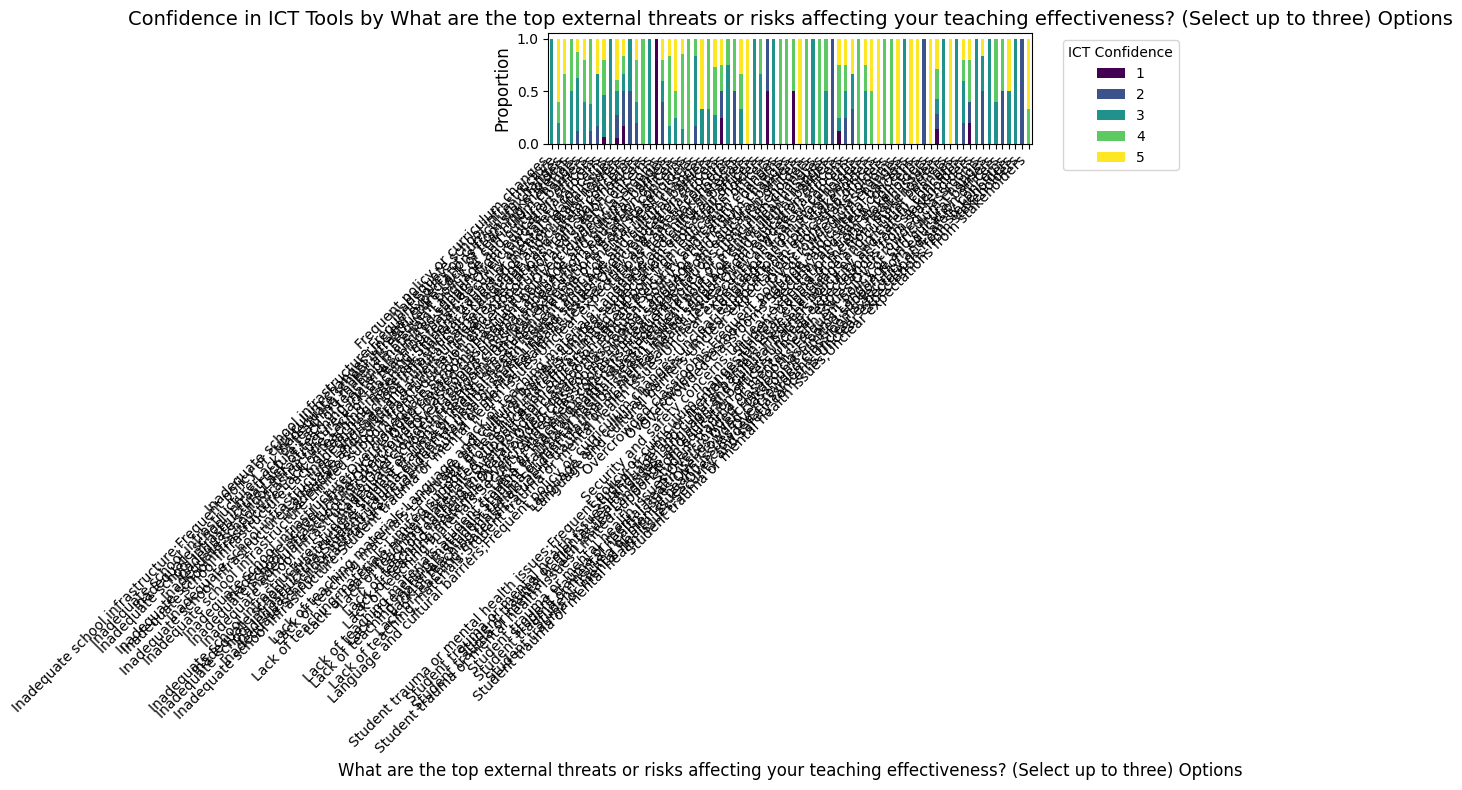

<ipython-input-23-2c8b843bc9b8>:134: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


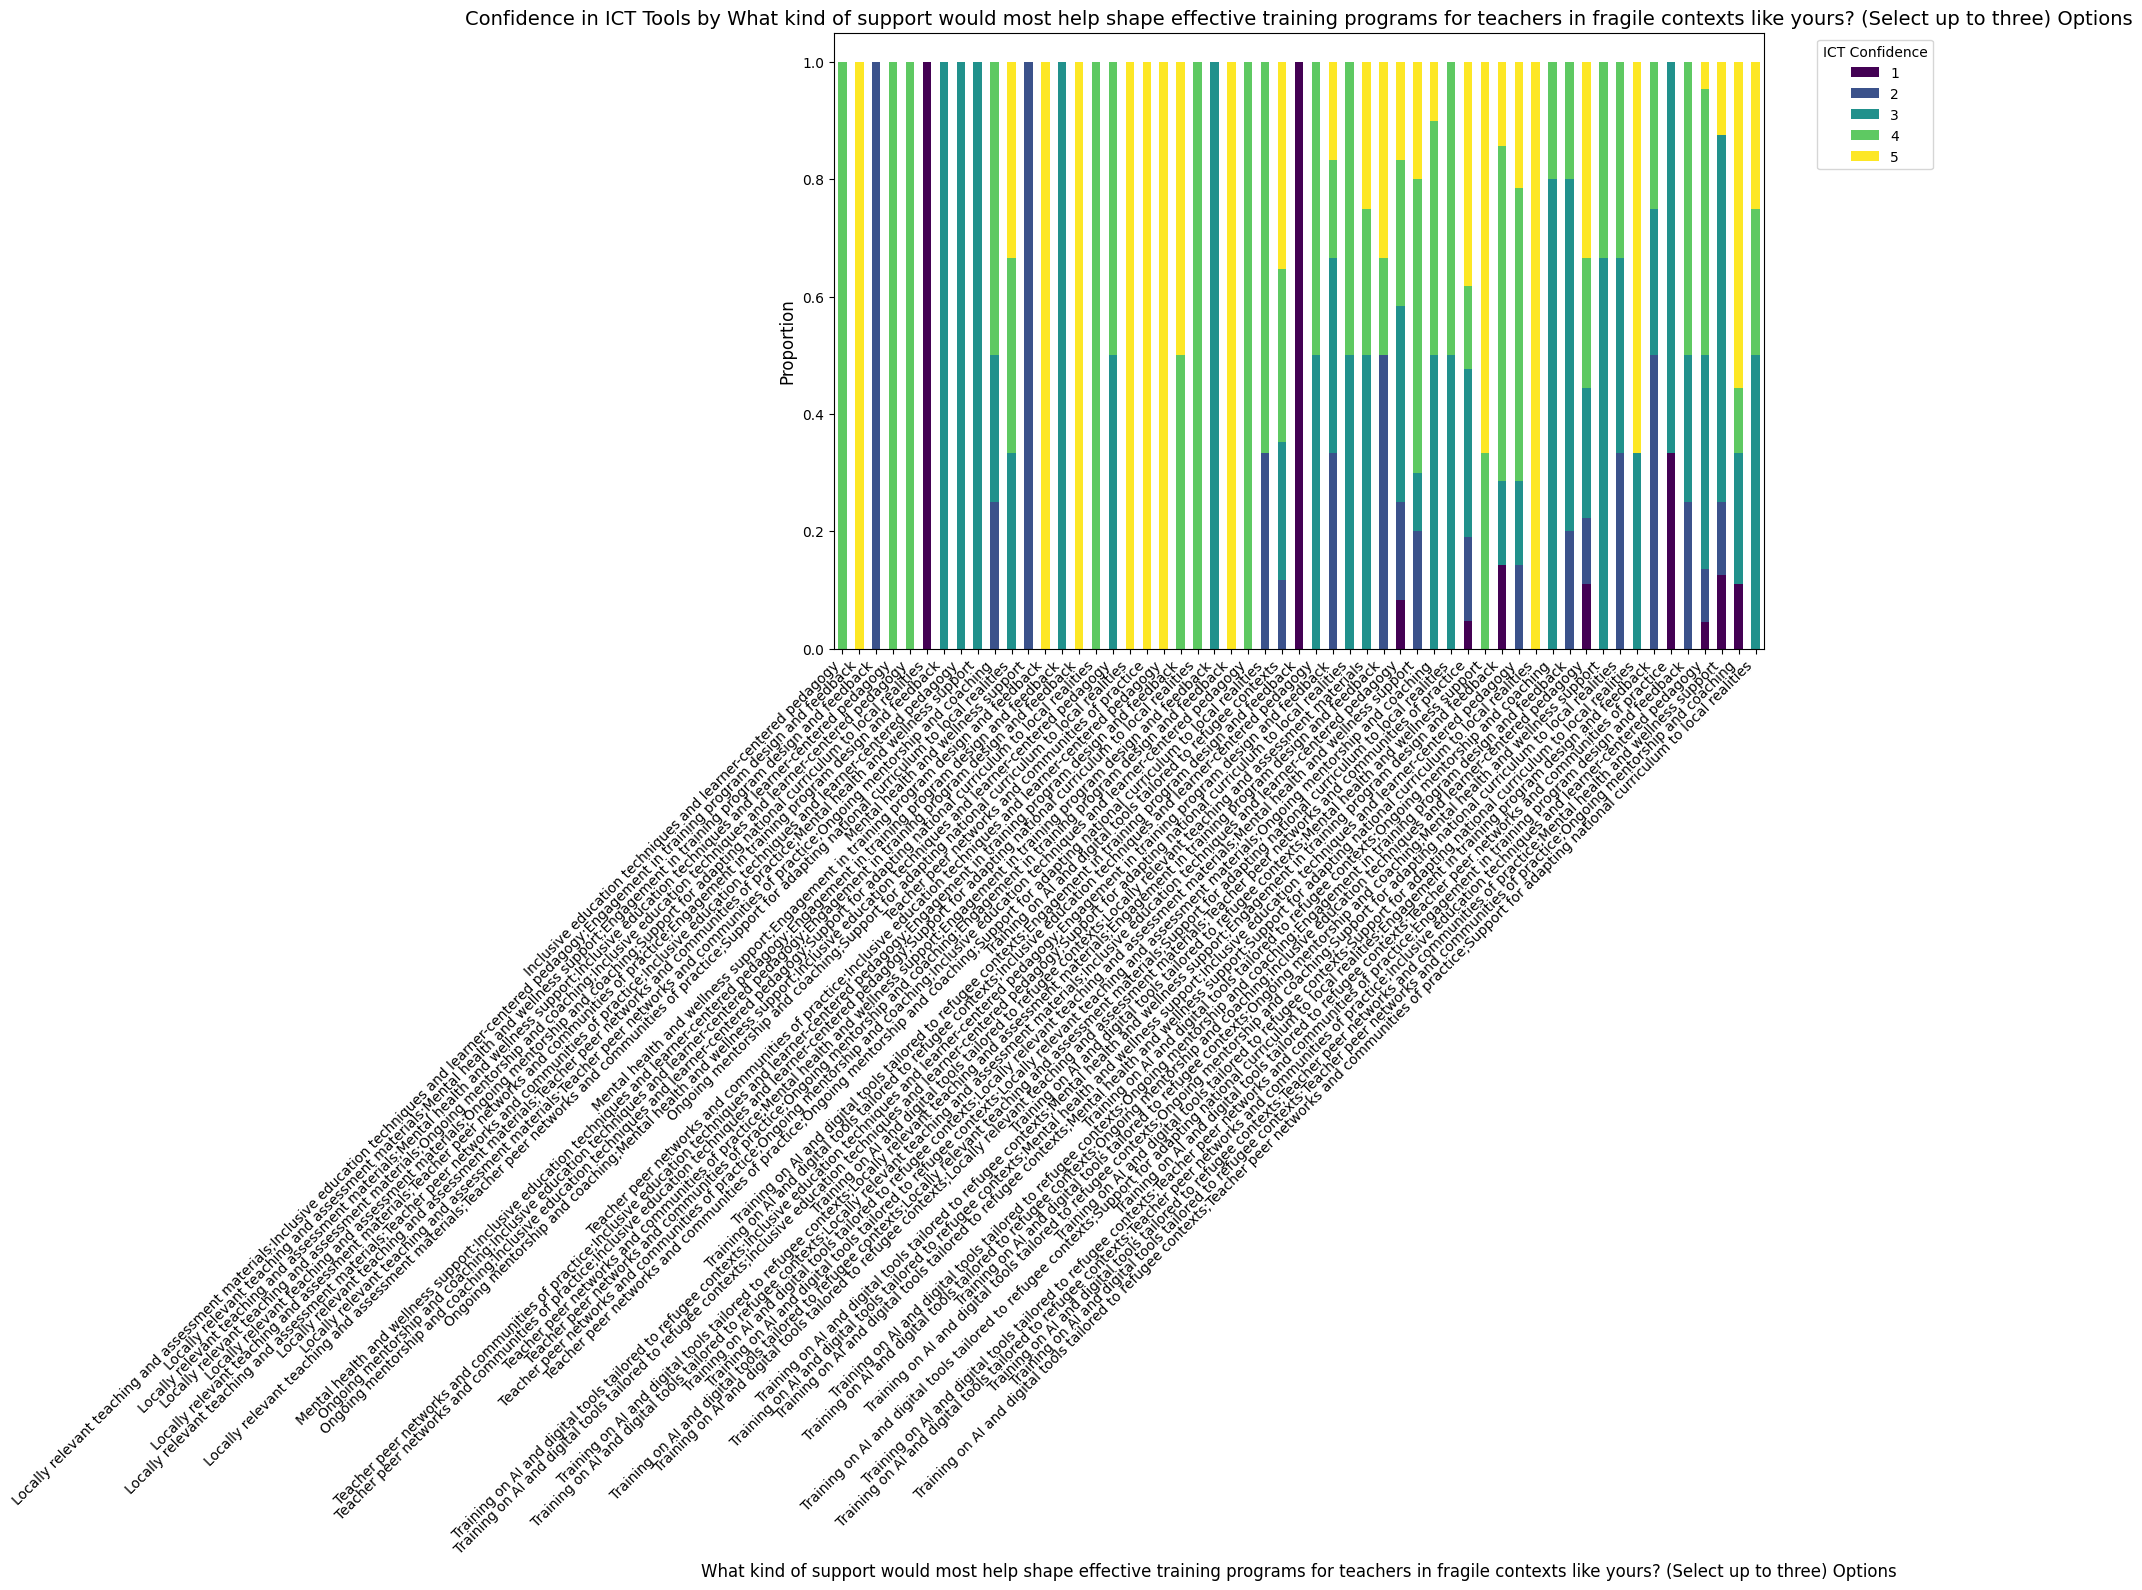


Checking column for Box Plot: 'Number of Years of Teaching Experience:'
Unique values: ['More than 10 years' '1–3 years' '7–10 years' '4–6 years'
 'Less than 1 year']
 'Less than 1 year']
Consider creating a stacked bar chart if 'Number of Years of Teaching Experience:' represents categorical ranges.

Generating Heatmap for 'Gender' vs 'Highest Level of Education Completed:'


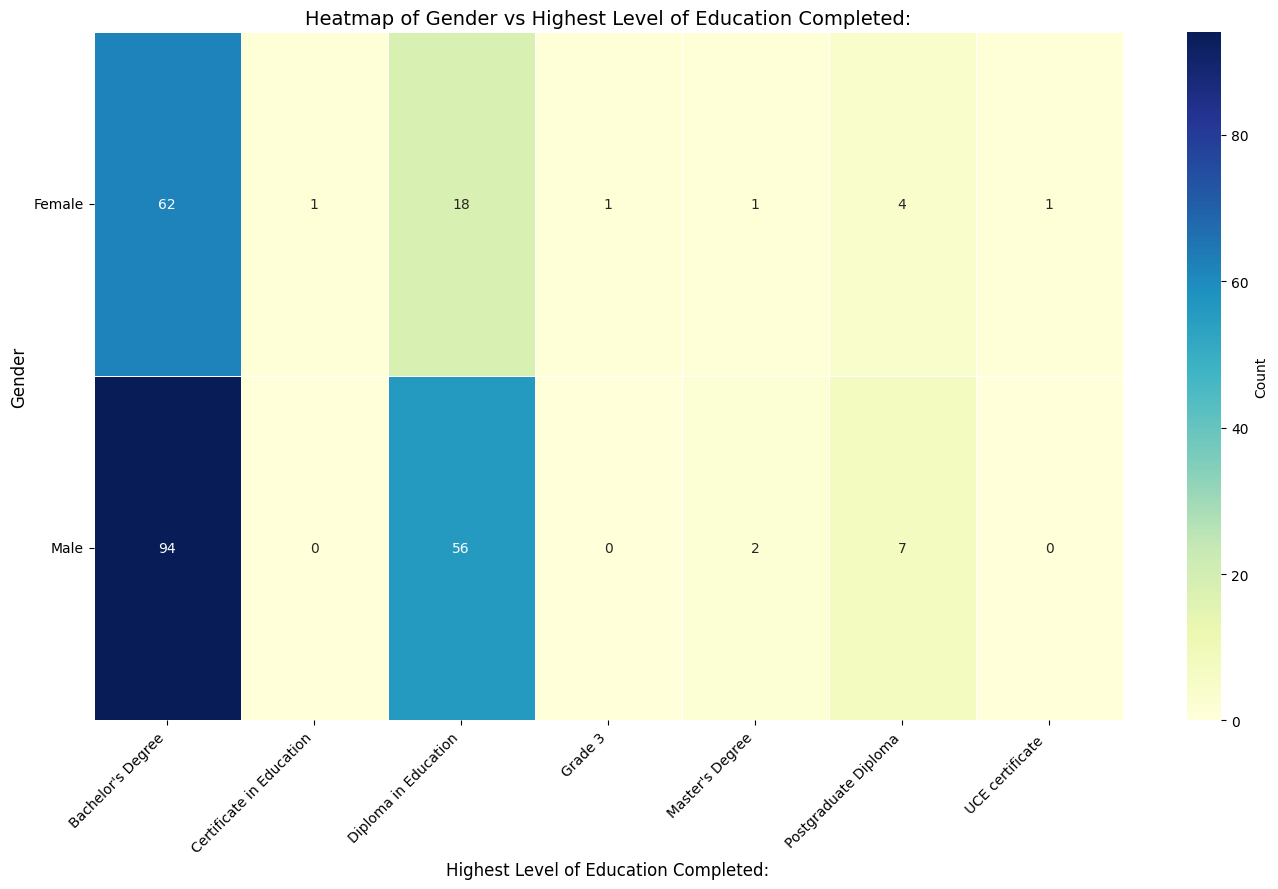


Generating Correlation Heatmap for One-Hot Encoded Variables:


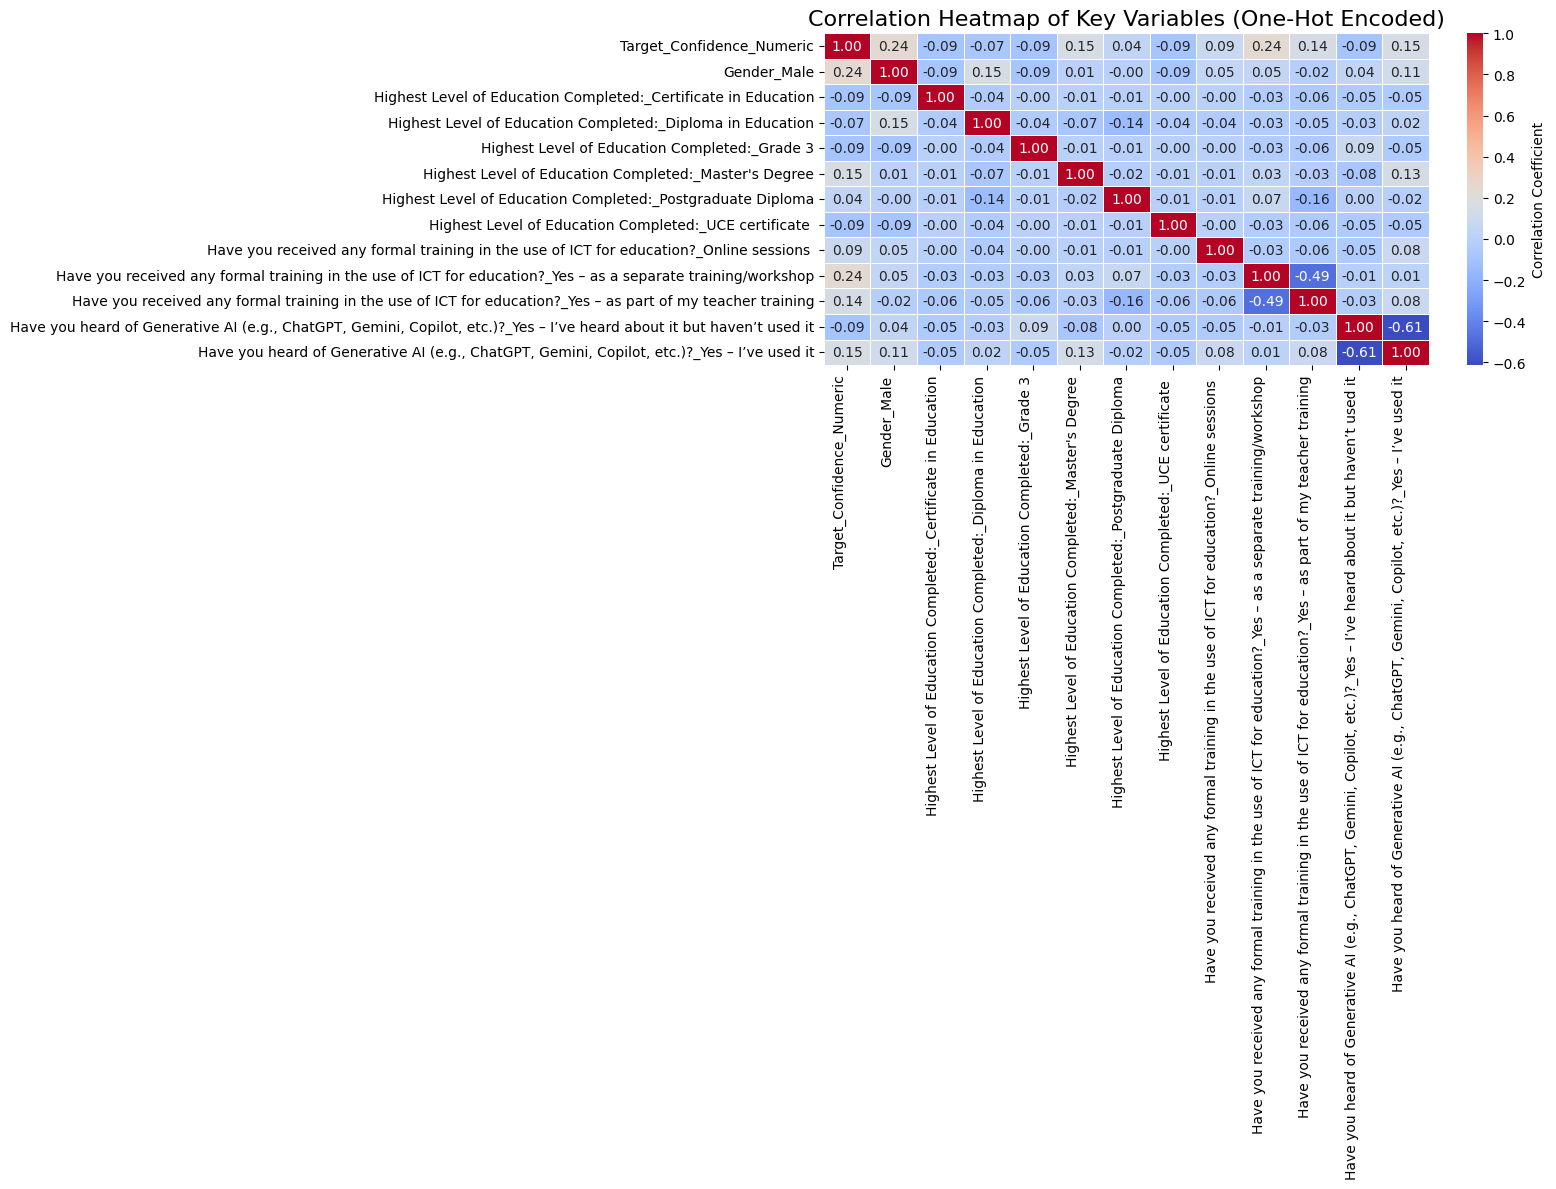

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import io

# --- IMPORTANT FOR COLAB USERS ---
# If your file is in Google Drive, you need to mount your Drive first.
# Uncomment the following lines in your Colab notebook to do this:
# from google.colab import drive
# drive.mount('/content/drive')

# Set the file path as requested by you
file_path = '/content/drive/MyDrive/diabetes/gai _teacher.csv'
df = pd.read_csv(file_path)

df.columns = df.columns.str.strip()


# Print all cleaned column names to verify (useful for debugging in Colab)
print("Cleaned DataFrame Columns:")
print(df.columns.tolist())

# Identify the target variable
target_variable = 'How confident are you in using ICT tools for teaching and learning?'

# Ensure the target variable exists in the DataFrame, try the alternative if not
if target_variable not in df.columns:
    print(f"Warning: Primary target variable '{target_variable}' not found. Checking alternative...")
    # Based on the previous output, the alternative was with '.1'
    target_variable = 'How confident are you in using ICT tools for teaching and learning?.1'
    if target_variable not in df.columns:
        print(f"Error: Neither of the specified target variables found. Please check the column names in your CSV.")
        exit() # Exit if the target variable is not found

print(f"\nUsing target variable: '{target_variable}'")
print("\nValue counts for the target variable:")
print(df[target_variable].value_counts())
print("\nUnique values in target variable:", df[target_variable].unique())


# --- 1. Pie Chart for Target Variable ---
plt.figure(figsize=(9, 9))
df[target_variable].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, cmap='Pastel1', pctdistance=0.85)
plt.title(f'Distribution of Teacher Confidence in Using ICT Tools for Teaching and Learning', fontsize=14)
plt.ylabel('') # Hide the default 'count' label
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

# --- 2. Stacked Bar Charts ---
# Corrected single-select categorical variables for stacked bar charts
# (These names are based on the cleaned DataFrame columns)
single_select_vars_for_stacked_bar = [
    'Gender',
    'Age Range',
    'Highest Level of Education Completed:',
    'Education Service Status',
    'Have you received any formal training in the use of ICT for education?', # Reverting to exact name based on potential original data
    'Have you heard of Generative AI (e.g., ChatGPT, Gemini, Copilot, etc.)?'
]

print("\nGenerating stacked bar charts for single-select variables:")
for col in single_select_vars_for_stacked_bar:
    if col in df.columns:
        # Create a crosstab and normalize to show proportions
        # Drop rows where either column has NaN for clean proportions
        crosstab_df = pd.crosstab(df[col], df[target_variable], normalize='index').dropna(how='all')
        if not crosstab_df.empty:
            ax = crosstab_df.plot(kind='bar', stacked=True, figsize=(10, 7), cmap='viridis')
            plt.title(f'Confidence in ICT Tools by {col}', fontsize=14)
            plt.xlabel(col, fontsize=12)
            plt.ylabel('Proportion', fontsize=12)
            plt.xticks(rotation=45, ha='right')
            plt.legend(title='ICT Confidence', bbox_to_anchor=(1.05, 1), loc='upper left')
            plt.tight_layout()
            plt.show()
        else:
            print(f"Skipping stacked bar for '{col}' due to no valid data after droppping NaNs.")
    else:
        print(f"Warning: Column '{col}' not found for stacked bar chart. Please check the exact column name.")


# --- Handling Multi-select columns for stacked bar charts ---
# Corrected multi-select column names (these are the exact names after cleaning)
multi_select_vars = [
    'Which subject(s) do you currently teach?',
    'Which topics would you like training in?',
    'Which organizations have provided you with training or support in the last 2 years? (Tick all that apply)',
    'How would you prefer to receive future training in AI and ICT for teaching? (Tick all that apply)',
    'What is the most limiting factor in using ICT or AI tools in your school? (Tick three)',
    'How do you usually adapt your lessons when teaching in challenging (low-resource or overcrowded) environments? (Tick all that apply)',
    'What are the top 3 strengths you personally bring as a teacher in fragile or refugee contexts? (Tick 3 only)',
    'What are the top 3 areas you feel you need the most support in as a teacher in these contexts? (Tick 3 only)',
    'What motivates you most to continue teaching in refugee or fragile contexts? (Tick all that apply)',
    'What challenges do you foresee in adopting Generative AI in fragile education systems? (Tick all that apply)',
    'Which of the following would help you improve your teaching most effectively? (Tick up to 3)',
    'Which external opportunities would most enhance your teaching in refugee or low-resource environments? (Select up to three)',
    'What are the top external threats or risks affecting your teaching effectiveness? (Select up to three)',
    'What kind of support would most help shape effective training programs for teachers in fragile contexts like yours? (Select up to three)'
]


# Filter multi-select columns to only include those present in the DataFrame
multi_select_vars_present = [col for col in multi_select_vars if col in df.columns]

print("\nGenerating stacked bar charts for present multi-select variables:")
for col in multi_select_vars_present:
    # Drop rows where the column is NaN or empty string before splitting
    temp_df = df[[col, target_variable]].dropna(subset=[col])
    if temp_df.empty:
        print(f"Skipping multi-select '{col}' as it contains no valid data.")
        continue

    # Split string entries by comma and expand to long format
    # Ensure values are strings before splitting to avoid errors
    s = temp_df[col].astype(str).str.split(',').explode()
    s = s.str.strip() # Remove leading/trailing whitespace from options

    # Create a DataFrame from the exploded series and merge with target variable
    exploded_df = s.to_frame(name='Option')
    exploded_df[target_variable] = temp_df[target_variable].loc[s.index]

    if not exploded_df.empty:
        # Create a crosstab for the exploded options vs. target variable
        crosstab_multiselect = pd.crosstab(exploded_df['Option'], exploded_df[target_variable], normalize='index')
        if not crosstab_multiselect.empty:
            # Plot only if there's data after normalization
            ax = crosstab_multiselect.plot(kind='bar', stacked=True, figsize=(12, 8), cmap='viridis')
            plt.title(f'Confidence in ICT Tools by {col} Options', fontsize=14)
            plt.xlabel(f'{col} Options', fontsize=12)
            plt.ylabel('Proportion', fontsize=12)
            plt.xticks(rotation=45, ha='right')
            plt.legend(title='ICT Confidence', bbox_to_anchor=(1.05, 1), loc='upper left')
            plt.tight_layout()
            plt.show()
        else:
            print(f"Skipping stacked bar for multi-select '{col}' due to no valid data after splitting and normalization.")
    else:
        print(f"Skipping multi-select '{col}' due to no valid data after exploding.")
if not multi_select_vars_present:
    print("No multi-select columns found in the DataFrame to plot stacked bars.")


# --- 3. Box Plots ---
# Check 'Number of Years of Teaching Experience:'
experience_col = 'Number of Years of Teaching Experience:'
if experience_col in df.columns:
    print(f"\nChecking column for Box Plot: '{experience_col}'")
    print("Unique values:", df[experience_col].unique())
    # Attempt to convert to numeric, coercing errors will turn non-numeric into NaN
    df[experience_col + '_numeric'] = pd.to_numeric(df[experience_col], errors='coerce')

    if pd.api.types.is_numeric_dtype(df[experience_col + '_numeric']) and df[experience_col + '_numeric'].notna().any():
        plt.figure(figsize=(10, 7))
        sns.boxplot(x=target_variable, y=experience_col + '_numeric', data=df, palette='viridis')
        plt.title(f'Teaching Experience by Confidence in ICT Tools', fontsize=14)
        plt.xlabel(target_variable, fontsize=12)
        plt.ylabel('Number of Years of Teaching Experience', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    else:
        print(f"Warning: Column '{experience_col}' is not suitable for a box plot (not numeric or all NaN after conversion). Its unique values are: {df[experience_col].unique()}")
        print(f"Consider creating a stacked bar chart if '{experience_col}' represents categorical ranges.")
else:
    print(f"Warning: Column '{experience_col}' not found for box plot.")


# --- 4. Heatmap ---
# Example: Heatmap of Gender vs. Highest Level of Education Completed
heatmap_var1 = 'Gender'
heatmap_var2 = 'Highest Level of Education Completed:'

if heatmap_var1 in df.columns and heatmap_var2 in df.columns:
    print(f"\nGenerating Heatmap for '{heatmap_var1}' vs '{heatmap_var2}'")
    # Create a contingency table (counts)
    contingency_table = pd.crosstab(df[heatmap_var1], df[heatmap_var2]).dropna(how='all', axis=0).dropna(how='all', axis=1)

    if not contingency_table.empty:
        plt.figure(figsize=(14, 9))
        sns.heatmap(contingency_table, annot=True, fmt='d', cmap='YlGnBu', linewidths=.5, cbar_kws={'label': 'Count'})
        plt.title(f'Heatmap of {heatmap_var1} vs {heatmap_var2}', fontsize=14)
        plt.xlabel(heatmap_var2, fontsize=12)
        plt.ylabel(heatmap_var1, fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()
    else:
        print(f"Skipping heatmap for '{heatmap_var1}' vs '{heatmap_var2}' due to no valid data after dropping NaNs.")
else:
    print(f"Warning: One or both columns '{heatmap_var1}' or '{heatmap_var2}' not found for heatmap.")

# --- Additional Heatmap with Target Variable (Correlation) ---
# Mapping for target confidence to numeric values
target_confidence_mapping = {
    '1': 1, # Assuming '1' means 'Not confident' or lowest scale point
    '2': 2,
    '3': 3,
    '4': 4,
    '5': 5  # Assuming '5' means 'Very confident' or highest scale point
    # Add more mappings if other categories exist, or adjust based on your data's labels
    # e.g., 'Not confident': 1, 'Slightly confident': 2, etc.
}

# Apply mapping, ensuring the target variable is treated as string for mapping keys
df['Target_Confidence_Numeric'] = df[target_variable].astype(str).map(target_confidence_mapping)

# Select relevant single-choice categorical variables and the numeric target for correlation heatmap.
selected_corr_vars = [
    'Gender',
    'Highest Level of Education Completed:',
    'Have you received any formal training in the use of ICT for education?', # Corrected name
    'Have you heard of Generative AI (e.g., ChatGPT, Gemini, Copilot, etc.)?',
    'Target_Confidence_Numeric'
]

# Filter columns that actually exist in the DataFrame
existing_corr_vars = [col for col in selected_corr_vars if col in df.columns]

# Create a temporary dataframe with only existing selected columns for one-hot encoding
df_corr_prep = df[existing_corr_vars].copy()

# Identify columns to one-hot encode (all except the numeric target)
cols_to_onehot = [col for col in existing_corr_vars if col != 'Target_Confidence_Numeric']

# One-hot encode categorical columns
df_corr_encoded = pd.get_dummies(df_corr_prep, columns=cols_to_onehot, drop_first=True)

# Calculate the correlation matrix
if 'Target_Confidence_Numeric' in df_corr_encoded.columns and df_corr_encoded['Target_Confidence_Numeric'].notna().any():
    print("\nGenerating Correlation Heatmap for One-Hot Encoded Variables:")
    correlation_matrix = df_corr_encoded.corr()

    # Remove rows/cols that are all NaN (e.g., if a category has no entries or only NaNs)
    correlation_matrix = correlation_matrix.dropna(how='all').dropna(how='all', axis=1)

    if not correlation_matrix.empty:
        plt.figure(figsize=(16, 12))
        sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5,
                    cbar_kws={'label': 'Correlation Coefficient'})
        plt.title('Correlation Heatmap of Key Variables (One-Hot Encoded)', fontsize=16)
        plt.xticks(rotation=90, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()
    else:
        print("Skipping correlation heatmap because the correlation matrix is empty after encoding and cleaning.")
else:
    print("Skipping correlation heatmap as the numeric target variable could not be prepared or has no valid data for correlation.")

data training testingand validating